In [53]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully")

Libraries imported successfully


In [54]:
# Load our clean parquet files

df_trips = pd.read_parquet('cleaned_data/clean_trips.parquet')
df_fuel_pur = pd.read_parquet('cleaned_data/clean_fuel_pur.parquet')
df_main_rec = pd.read_parquet('cleaned_data/clean_main_rec.parquet')
df_trucks = pd.read_parquet('cleaned_data/clean_trucks.parquet')


In [55]:
# Aggregate Trips, Fuel_Spend, Maintenance Cost per Fleet (Fleet == 'Truck' here)

# Aggregate Trip Table per Truck

truck_trips = df_trips.groupby('truck_id').agg(
    total_miles=('actual_distance_miles', 'sum'),
    total_duration_hours=('actual_duration_hours', 'sum'),
    total_gallons_used=('fuel_gallons_used', 'sum'),
    total_idle_hours=('idle_time_hours', 'sum'),
    total_trips_completed=('trip_id', 'count')
).reset_index()

# Aggregate Fuel Purchase Table per Truck

truck_fuel_spend = df_fuel_pur.groupby('truck_id').agg(
    total_fuel_cost=('total_cost', 'sum'),
    total_fuel_transactions=('fuel_purchase_id', 'count')
).reset_index()

# Aggregate Maintenance Table per Truck
# We split labor and parts to evaluate what type of work drives asset aging costs

truck_maintenance = df_main_rec.groupby('truck_id').agg(
    total_maint_cost=('total_cost', 'sum'),
    total_labor_cost=('labor_cost', 'sum'),
    total_parts_cost=('parts_cost', 'sum'),
    total_downtime_hours=('downtime_hours', 'sum'),
    maintenance_events=('maintenance_id', 'count')
).reset_index()

In [56]:
# Merge all aggregated components with Truck Table together

df_fleet_master = df_trucks.merge(truck_trips, on='truck_id', how='left')
df_fleet_master = df_fleet_master.merge(truck_fuel_spend, on='truck_id', how='left')
df_fleet_master = df_fleet_master.merge(truck_maintenance, on='truck_id', how='left')

df_fleet_master

,truck_id,unit_number,make,model_year,vin,acquisition_date,acquisition_mileage,fuel_type,tank_capacity_gallons,status,home_terminal,total_miles,total_duration_hours,total_gallons_used,total_idle_hours,total_trips_completed,total_fuel_cost,total_fuel_transactions,total_maint_cost,total_labor_cost,total_parts_cost,total_downtime_hours,maintenance_events
0,TRK00001,3463,Peterbilt,2016,1VV205190335317039,2017-04-27,18814,Diesel,200,Active,Omaha,1356397.0,23794.2,210762.2,6564.1,951.0,1086194.17,2214.0,51775.99,10191.51,41584.48,713.2,24
1,TRK00002,6461,Kenworth,2015,1NV753749606229960,2018-10-04,26795,Diesel,150,Active,Seattle,1270572.0,22222.8,197770.4,6255.9,887.0,995986.71,2042.0,54869.04,13165.89,41703.15,665.3,27
2,TRK00003,2335,Peterbilt,2018,1NT803101860493229,2020-09-17,11795,Diesel,150,Maintenance,Atlanta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90161.42,18587.94,71573.48,1133.1,41
3,TRK00004,3317,Freightliner,2015,1VV131945381692351,2017-06-17,8875,Diesel,200,Active,Salt Lake City,1309547.0,22994.8,203200.2,6412.0,929.0,1034663.13,2152.0,38561.82,7697.22,30864.60,483.2,22
4,TRK00005,6731,Freightliner,2016,1FT822215709701985,2021-10-08,42042,Diesel,250,Maintenance,Miami,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66088.45,16406.00,49682.45,750.6,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,TRK00116,3449,International,2019,1MV446968103715126,2020-12-10,19653,Diesel,200,Active,Kansas City,1310738.0,22767.1,203218.4,6330.4,906.0,1018895.11,2088.0,39736.84,7410.59,32326.25,366.2,18
116,TRK00117,9991,Peterbilt,2015,1FU939700479057712,2015-09-30,24671,Diesel,150,Inactive,New York,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25579.03,4804.04,20774.99,271.0,15
117,TRK00118,9647,Freightliner,2015,1NV150990165397549,2017-09-01,12050,Diesel,150,Inactive,Detroit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71005.77,15815.53,55190.24,917.3,35
118,TRK00119,7934,Mack,2015,1MU171789091515507,2018-10-26,49441,Diesel,250,Inactive,Seattle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43409.10,10545.17,32863.93,489.6,24


In [57]:
# Check the missing values in Merge Dataframe 'df_fleet_master'

df_fleet_master. isnull().sum()

truck_id                    0
unit_number                 0
make                        0
model_year                  0
vin                         0
acquisition_date            0
acquisition_mileage         0
fuel_type                   0
tank_capacity_gallons       0
status                      0
home_terminal               0
total_miles                28
total_duration_hours       28
total_gallons_used         28
total_idle_hours           28
total_trips_completed      28
total_fuel_cost            28
total_fuel_transactions    28
total_maint_cost            0
total_labor_cost            0
total_parts_cost            0
total_downtime_hours        0
maintenance_events          0
dtype: int64

In [58]:
# Filling missing values in Merge Dataframe 'df_fleet_master' 

## Assumption: There are some trucks with no trips and hence no fuel_purchase records. As they don't have any trips/ fuel_purchse, ideally their total_miles, total_trips_completed should be 0. Thus, missing values are replaced with 0. 

fill_cols = [
    'total_miles', 'total_duration_hours', 'total_gallons_used', 'total_idle_hours',
    'total_trips_completed', 'total_fuel_cost', 'total_fuel_transactions'
]
df_fleet_master[fill_cols] = df_fleet_master[fill_cols].fillna(0)


In [59]:
# Check whether missing values in Merge Dataframe 'df_fleet_master' filled

df_fleet_master.isnull().sum()

truck_id                   0
unit_number                0
make                       0
model_year                 0
vin                        0
acquisition_date           0
acquisition_mileage        0
fuel_type                  0
tank_capacity_gallons      0
status                     0
home_terminal              0
total_miles                0
total_duration_hours       0
total_gallons_used         0
total_idle_hours           0
total_trips_completed      0
total_fuel_cost            0
total_fuel_transactions    0
total_maint_cost           0
total_labor_cost           0
total_parts_cost           0
total_downtime_hours       0
maintenance_events         0
dtype: int64

In [60]:
# Feature Engineering: Calculate key derived performance metrics

df_fleet_master['calculated_mpg'] = np.where(
    df_fleet_master['total_gallons_used'] > 0,
    df_fleet_master['total_miles'] / df_fleet_master['total_gallons_used'], 
    0
)
df_fleet_master['idle_time_pct'] = np.where(
    df_fleet_master['total_duration_hours'] > 0,
    (df_fleet_master['total_idle_hours'] / df_fleet_master['total_duration_hours']) * 100,
    0
)
df_fleet_master['truck_age_years'] = datetime.datetime.now().year - df_fleet_master['model_year']


In [61]:
df_fleet_master

,truck_id,unit_number,make,model_year,vin,acquisition_date,acquisition_mileage,fuel_type,tank_capacity_gallons,status,home_terminal,total_miles,total_duration_hours,total_gallons_used,total_idle_hours,total_trips_completed,total_fuel_cost,total_fuel_transactions,total_maint_cost,total_labor_cost,total_parts_cost,total_downtime_hours,maintenance_events,calculated_mpg,idle_time_pct,truck_age_years
0,TRK00001,3463,Peterbilt,2016,1VV205190335317039,2017-04-27,18814,Diesel,200,Active,Omaha,1356397.0,23794.2,210762.2,6564.1,951.0,1086194.17,2214.0,51775.99,10191.51,41584.48,713.2,24,6.435675,27.586975,10
1,TRK00002,6461,Kenworth,2015,1NV753749606229960,2018-10-04,26795,Diesel,150,Active,Seattle,1270572.0,22222.8,197770.4,6255.9,887.0,995986.71,2042.0,54869.04,13165.89,41703.15,665.3,27,6.424480,28.150818,11
2,TRK00003,2335,Peterbilt,2018,1NT803101860493229,2020-09-17,11795,Diesel,150,Maintenance,Atlanta,0.0,0.0,0.0,0.0,0.0,0.00,0.0,90161.42,18587.94,71573.48,1133.1,41,0.000000,0.000000,8
3,TRK00004,3317,Freightliner,2015,1VV131945381692351,2017-06-17,8875,Diesel,200,Active,Salt Lake City,1309547.0,22994.8,203200.2,6412.0,929.0,1034663.13,2152.0,38561.82,7697.22,30864.60,483.2,22,6.444615,27.884565,11
4,TRK00005,6731,Freightliner,2016,1FT822215709701985,2021-10-08,42042,Diesel,250,Maintenance,Miami,0.0,0.0,0.0,0.0,0.0,0.00,0.0,66088.45,16406.00,49682.45,750.6,33,0.000000,0.000000,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,TRK00116,3449,International,2019,1MV446968103715126,2020-12-10,19653,Diesel,200,Active,Kansas City,1310738.0,22767.1,203218.4,6330.4,906.0,1018895.11,2088.0,39736.84,7410.59,32326.25,366.2,18,6.449898,27.805034,7
116,TRK00117,9991,Peterbilt,2015,1FU939700479057712,2015-09-30,24671,Diesel,150,Inactive,New York,0.0,0.0,0.0,0.0,0.0,0.00,0.0,25579.03,4804.04,20774.99,271.0,15,0.000000,0.000000,11
117,TRK00118,9647,Freightliner,2015,1NV150990165397549,2017-09-01,12050,Diesel,150,Inactive,Detroit,0.0,0.0,0.0,0.0,0.0,0.00,0.0,71005.77,15815.53,55190.24,917.3,35,0.000000,0.000000,11
118,TRK00119,7934,Mack,2015,1MU171789091515507,2018-10-26,49441,Diesel,250,Inactive,Seattle,0.0,0.0,0.0,0.0,0.0,0.00,0.0,43409.10,10545.17,32863.93,489.6,24,0.000000,0.000000,11


In [62]:
# Save this dataset so we can instantly reload it later

df_fleet_master.to_parquet('cleaned_data/fleet_master_summary.parquet')
print("Fleet Master Dataframe Created Successfully!")

Fleet Master Dataframe Created Successfully!


Answering Key Business Questions with Data Visualization

Q1: Does maintenance cost scale as a truck ages, and at what age does a truck become financially unviable to keep in the fleet?

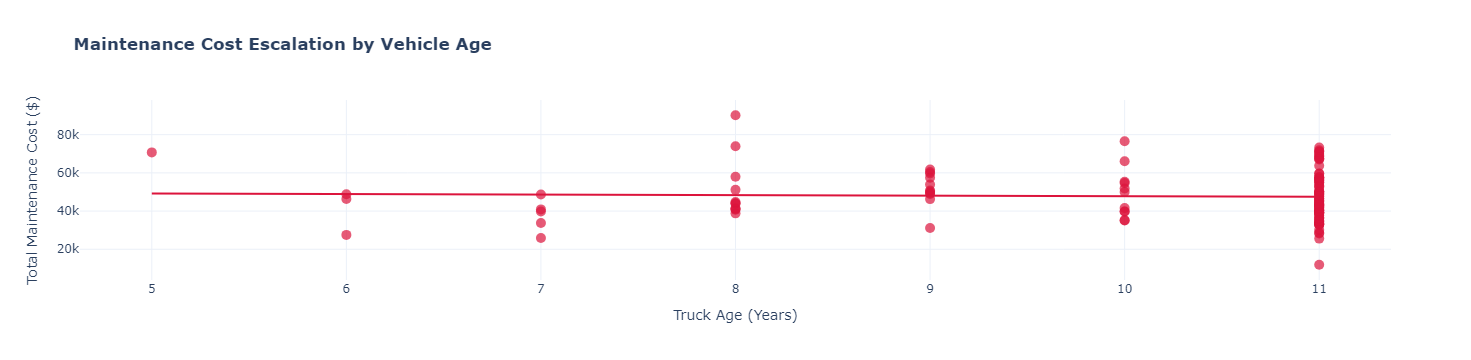

In [63]:
fig = px.scatter(
    df_fleet_master, 
    x='truck_age_years', 
    y='total_maint_cost',
    trendline='ols',
    hover_data=['truck_id', 'make', 'model_year'],
    title='<b>Maintenance Cost Escalation by Vehicle Age</b>',
    labels={'truck_age_years': 'Truck Age (Years)', 'total_maint_cost': 'Total Maintenance Cost ($)'},
    template='plotly_white'
)
fig.update_traces(marker=dict(size=10, opacity=0.7, color='crimson'))
fig.show()

Q2: Which vehicle manufacturer or model are achieving the best fuel efficiency?

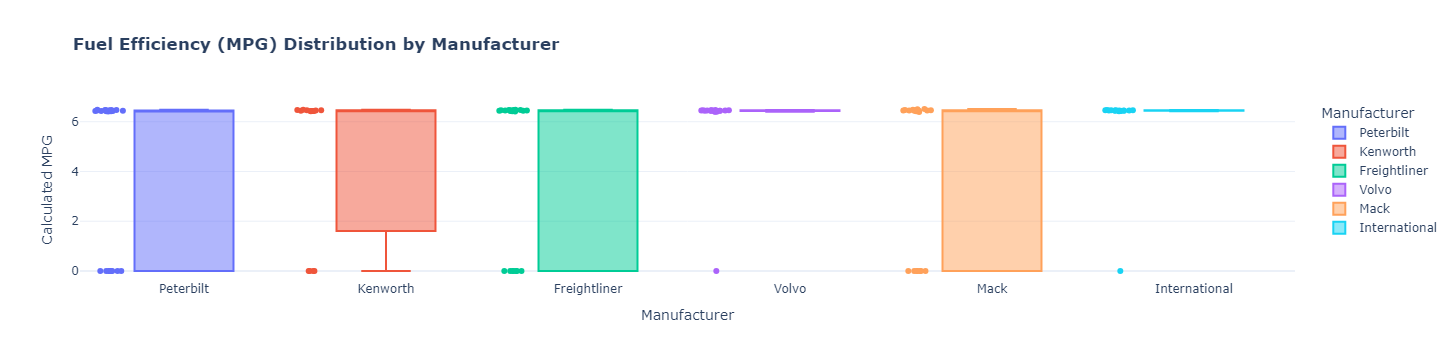

In [64]:
fig = px.box(
    df_fleet_master, 
    x='make', 
    y='calculated_mpg',
    points='all',  # Shows all individual data points next to the box
    hover_data=['truck_id'],
    title='<b>Fuel Efficiency (MPG) Distribution by Manufacturer</b>',
    labels={'make': 'Manufacturer', 'calculated_mpg': 'Calculated MPG'},
    color='make',
    template='plotly_white'
)
fig.show()

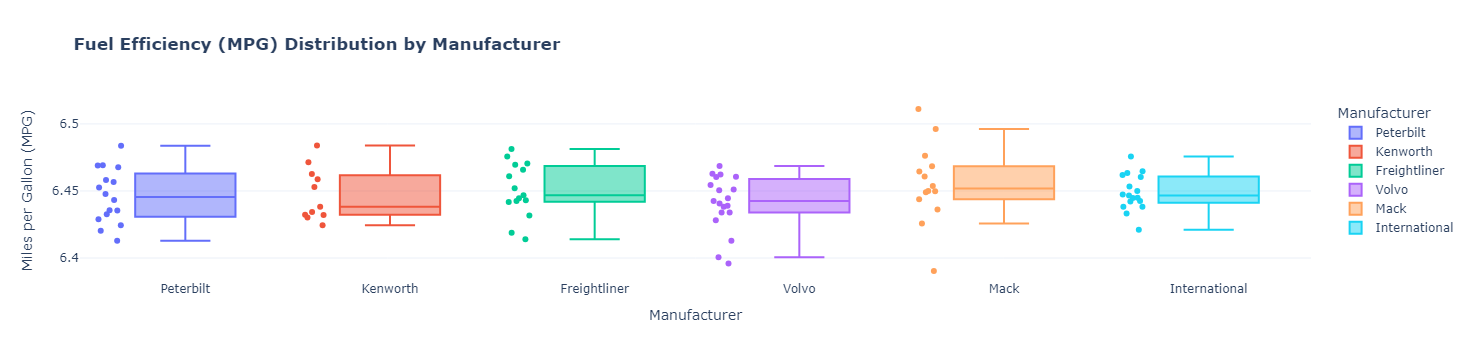

In [65]:
# Filter the dataframe to exclude rows where MPG is 0 or less
df_filtered = df_fleet_master[df_fleet_master['calculated_mpg'] > 0]

# --- BOX PLOT again with clean data ---
fig_box = px.box(
    df_filtered, 
    x='make', 
    y='calculated_mpg',
    points='all',  # Shows all individual data points next to the box
    hover_data=['truck_id'],
    title='<b>Fuel Efficiency (MPG) Distribution by Manufacturer</b>',
    labels={'make': 'Manufacturer', 'calculated_mpg': 'Miles per Gallon (MPG)'},
    color='make',
    template='plotly_white'
)
fig_box.show()

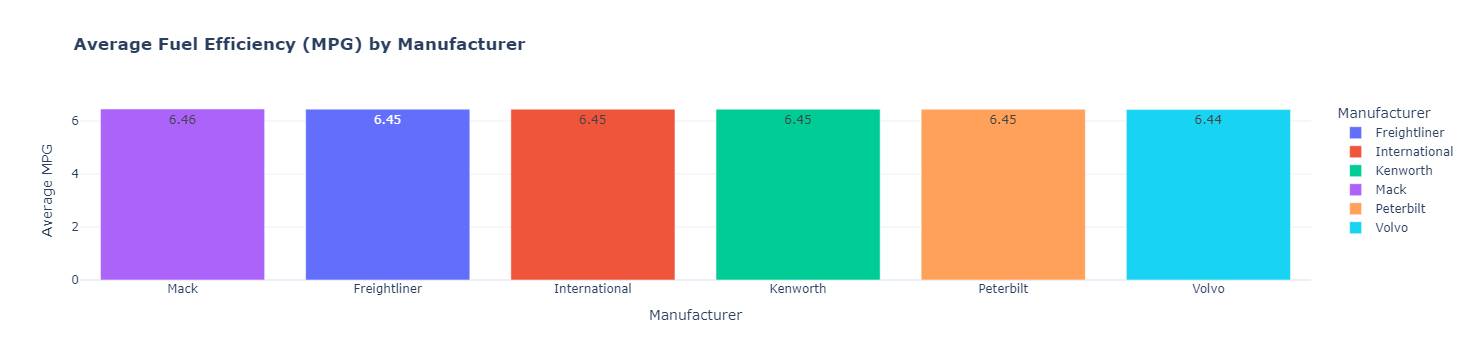

In [73]:
# --- Compare Fleet_Manufacturer based on Fuel Efficiency (MPG) with BAR PLOT ---

# We first aggregate the data by taking the average (mean) of the calculated MPG for each manufacturer

df_bar_data = df_filtered.groupby('make')['calculated_mpg'].mean().reset_index()

# --- BAR PLOT ---

fig_bar = px.bar(
    df_bar_data,
    x='make',
    y='calculated_mpg',
    title='<b>Average Fuel Efficiency (MPG) by Manufacturer</b>',
    labels={'make': 'Manufacturer', 'calculated_mpg': 'Average MPG'},
    color='make',
    text_auto='.2f',  # Automatically displays the exact average value on top of each bar
    template='plotly_white'
)

# Sort the X-axis categories in descending order based on the Y-axis values
fig_bar.update_layout(xaxis={'categoryorder': 'total descending'})

fig_bar.show()

Q3: Which home terminals have highest idle hours?

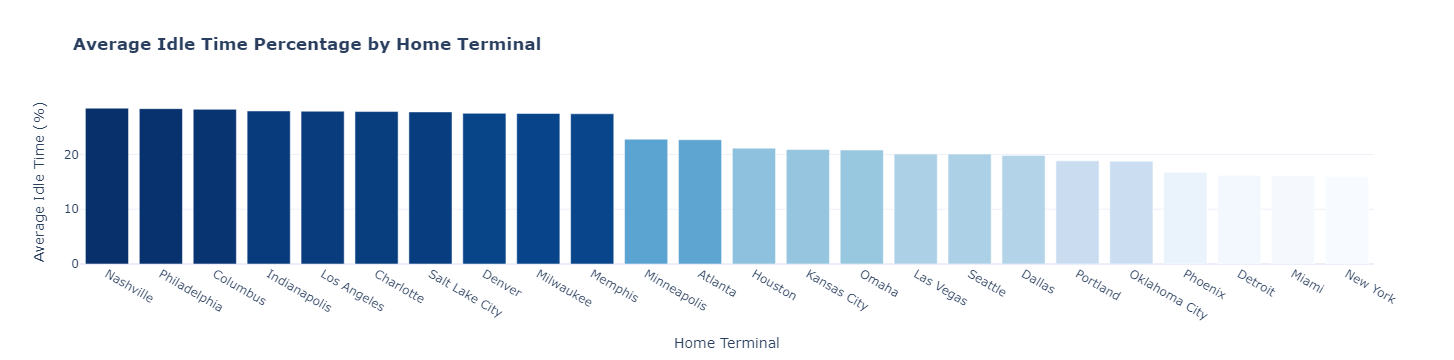

In [67]:
# Aggregate data first for clean plotting

df_idle = df_fleet_master.groupby('home_terminal', as_index=False)['idle_time_pct'].mean()
df_idle = df_idle.sort_values(by='idle_time_pct', ascending=False)

fig = px.bar(
    df_idle, 
    x='home_terminal', 
    y='idle_time_pct',
    title='<b>Average Idle Time Percentage by Home Terminal</b>',
    labels={'home_terminal': 'Home Terminal', 'idle_time_pct': 'Average Idle Time (%)'},
    color='idle_time_pct',
    color_continuous_scale='Blues',
    template='plotly_white'
)
fig.update_layout(coloraxis_showscale=False)
fig.show()

Q4: Which trucks have highest operational cost (TCO per mile)? 

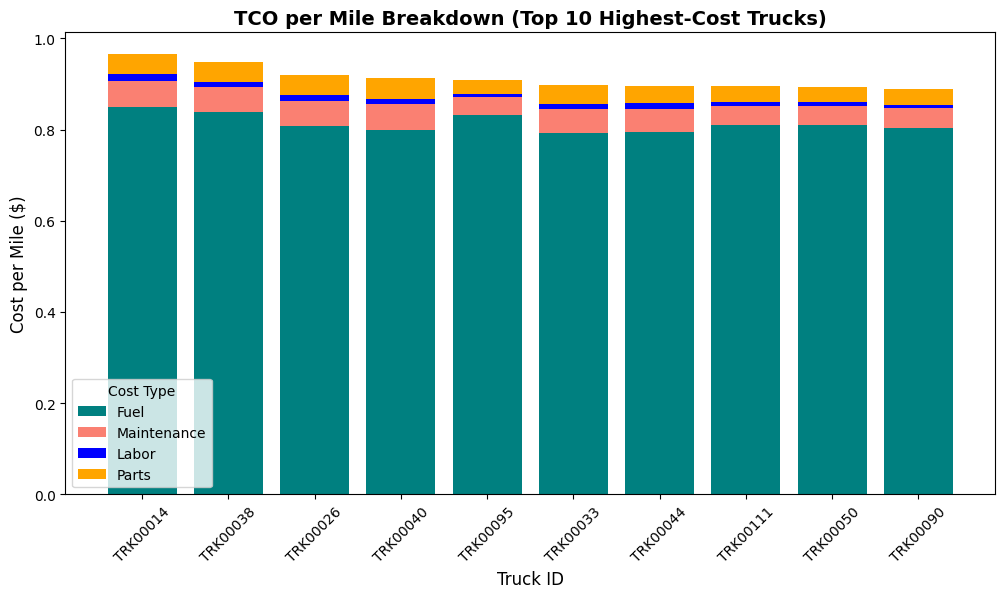

In [68]:
# Calculate TCO first and select top 10 trucks based on TCO

df_tco = df_fleet_master.copy()
df_tco['fuel_cost_per_mile'] = df_tco['total_fuel_cost'] / df_tco['total_miles']
df_tco['maint_cost_per_mile'] = df_tco['total_maint_cost'] / df_tco['total_miles']
df_tco['labor_cost_per_mile'] = df_tco['total_labor_cost'] / df_tco['total_miles']
df_tco['parts_cost_per_mile'] = df_tco['total_parts_cost'] / df_tco['total_miles']

df_tco['total_tco_per_mile'] = (
    df_tco['fuel_cost_per_mile'] + 
    df_tco['maint_cost_per_mile'] + 
    df_tco['labor_cost_per_mile'] + 
    df_tco['parts_cost_per_mile']
)

df_top10 = df_tco.sort_values(by='total_tco_per_mile', ascending=False).head(10)

# Set figure

plt.figure(figsize=(12,6))

# Base bar positions

x = range(len(df_top10))
truck_ids = df_top10['truck_id']

# Plot stacked bars

plt.bar(x, df_top10['fuel_cost_per_mile'], label='Fuel', color='teal')
plt.bar(x, df_top10['maint_cost_per_mile'], bottom=df_top10['fuel_cost_per_mile'], label='Maintenance', color='salmon')
plt.bar(x, df_top10['labor_cost_per_mile'], bottom=df_top10['fuel_cost_per_mile'] + df_top10['maint_cost_per_mile'], label='Labor', color='blue')
plt.bar(x, df_top10['parts_cost_per_mile'], bottom=df_top10['fuel_cost_per_mile'] + df_top10['maint_cost_per_mile'] + df_top10['labor_cost_per_mile'], label='Parts', color='orange')

# Labels and title

plt.xticks(x, truck_ids, rotation=45)
plt.xlabel('Truck ID', fontsize=12)
plt.ylabel('Cost per Mile ($)', fontsize=12)
plt.title('TCO per Mile Breakdown (Top 10 Highest-Cost Trucks)', fontsize=14, fontweight='bold')
plt.legend(title='Cost Type')
plt.show()

Q5: Is there a strong correlation between the number of maintenance events and total downtime hours, or are a few major catastrophic failures driving our fleet's downtime?

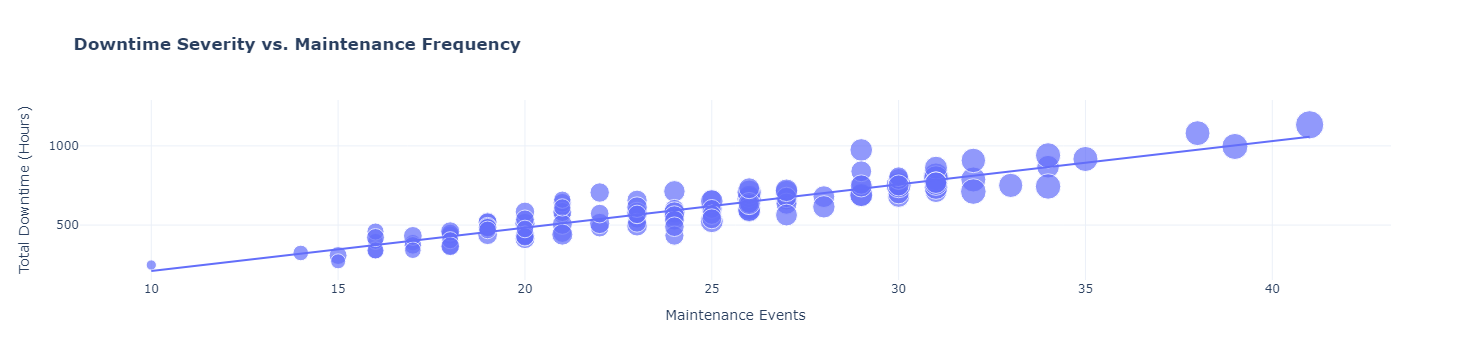

In [78]:
fig = px.scatter(
    df_fleet_master, 
    x='maintenance_events', 
    y='total_downtime_hours',
    size='total_maint_cost',
    trendline='ols',
    hover_data=['truck_id', 'total_maint_cost'],
    title='<b>Downtime Severity vs. Maintenance Frequency</b>',
    labels={'maintenance_events': 'Maintenance Events', 'total_downtime_hours': 'Total Downtime (Hours)'},
    template='plotly_white'
)
fig.show()

Q6: Which trucks are most/least utilized? 

In [70]:
# Top 5 most heavily utilized trucks by miles driven
most_utilized = df_fleet_master.sort_values(by='total_miles', ascending=False).head(5)

# Bottom 5 least utilized trucks (filtering out units that are completely out of service)
least_utilized = df_fleet_master[df_fleet_master['total_miles'] > 0].sort_values(by='total_miles', ascending=True).head(5)

print("--- Top 5 Workhorse Trucks ---")
print(most_utilized[['truck_id', 'make', 'model_year', 'total_miles']])

print("\n--- Bottom 5 Workhorse Trucks ---")
print(least_utilized[['truck_id', 'make', 'model_year', 'total_miles']])

--- Top 5 Workhorse Trucks ---
     truck_id           make  model_year  total_miles
54   TRK00055      Peterbilt        2017    1417530.0
40   TRK00041  International        2015    1404001.0
43   TRK00044          Volvo        2015    1403922.0
106  TRK00107           Mack        2017    1389705.0
14   TRK00015  International        2015    1386604.0

--- Bottom 5 Workhorse Trucks ---
     truck_id           make  model_year  total_miles
39   TRK00040  International        2015    1178515.0
17   TRK00018  International        2015    1194175.0
78   TRK00079           Mack        2015    1195812.0
107  TRK00108          Volvo        2015    1199508.0
35   TRK00036      Peterbilt        2020    1205829.0
